- ~~read DBSCAN documentation~~
- ~~complete the DBSCAN notes with examples~~
- ~~write k-nearest graph code on utils~~
- compare density-based clustering with partitioning-based clustering via example
- mention the problem with the DBSCAN algorithm
- read OPTICS documentation
- done a clustering project on the iris dataset set using:
	- k-means algorithm
	- DBSCAN
	- OPTICS
	- use and interpret the evaluation metrics

# DBSCAN: a density-based clustering method

**core concepts:**
- core point
- border point
- noise
- directly density-reachable
- density-reachable

**Hyperparameters:**
- epsilon
- min_points

This algorithm can catch different arbitrary shapes of clusters and look at the clusters as a dense space of data points. Unlike the partitioning-based methods like k-means clustering that can just capture spherical shapes of cluster with constant variance this method can handle non-linear cluster shapes. One of the most important pros of this algorithm is that there is no need to determine the number of clusters manualy and it will shape any number of clusters it foung during the fit process.

There is some problems with this algorithm like it needs hypertuning for the params in it but the most notable issue with this algorithm is it struggle handling data that has clusters with varying variance.

> **Note:** Pay attention to this point that clustering has an exploratory nature and should bring data insights so always be sure to interpret the clustering and evaluate and verify it using domain expertise knowledge.

In [130]:
# generating sample data
from sklearn.datasets import make_blobs, make_moons, make_s_curve

X1, y1 = make_blobs(
    n_samples=1500, n_features=2, centers=4, random_state=42,
    cluster_std=0.8
    
)
X2, y2 = make_moons(n_samples=1500, noise=0.1, random_state=42)
X3, y3 = make_s_curve(n_samples=1500, noise=0.1, random_state=42)

Text(0.5, 1.0, 'S-Curve Data set')

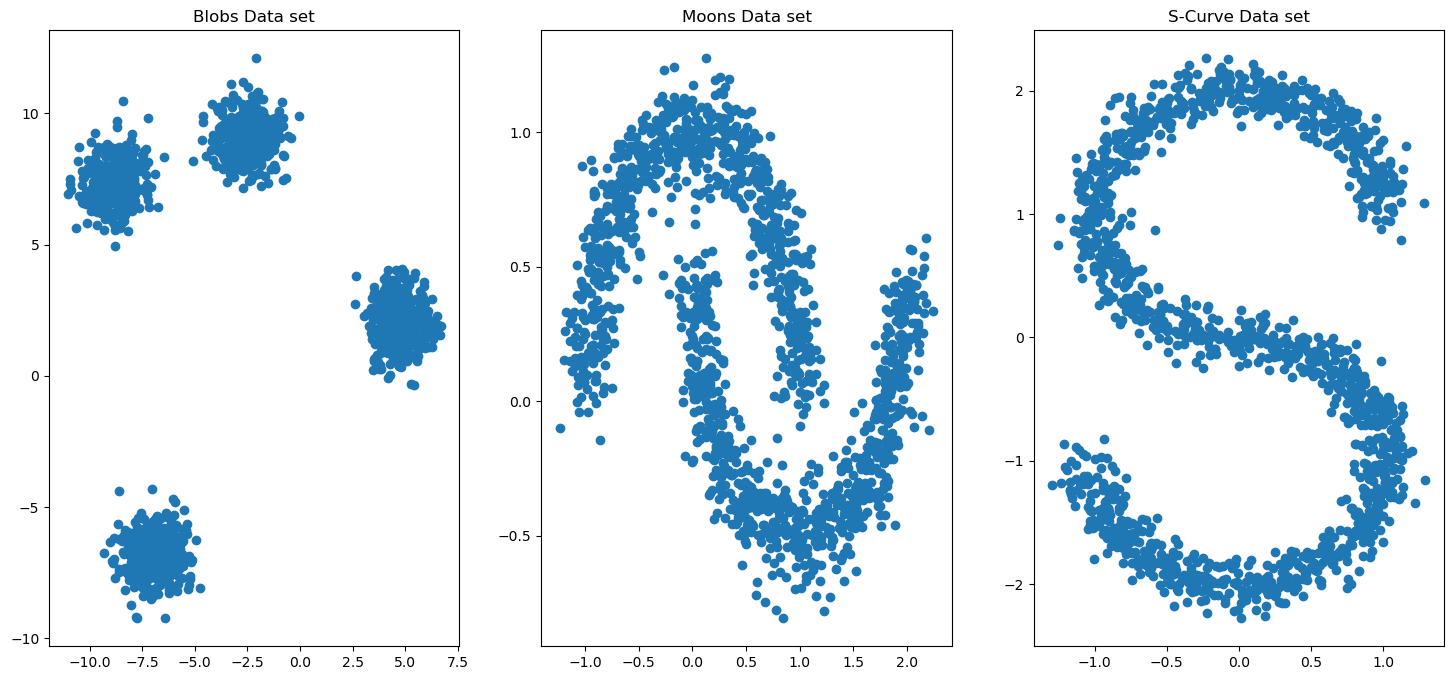

In [131]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 8))

ax1.scatter(X1[:, 0], X1[:, 1])
ax1.set_title("Blobs Data set")

ax2.scatter(X2[:, 0], X2[:, 1])
ax2.set_title("Moons Data set")

ax3.scatter(X3[:, 0], X3[:, 2])
ax3.set_title("S-Curve Data set")

Text(0.5, 1.0, 'Clustered Data')

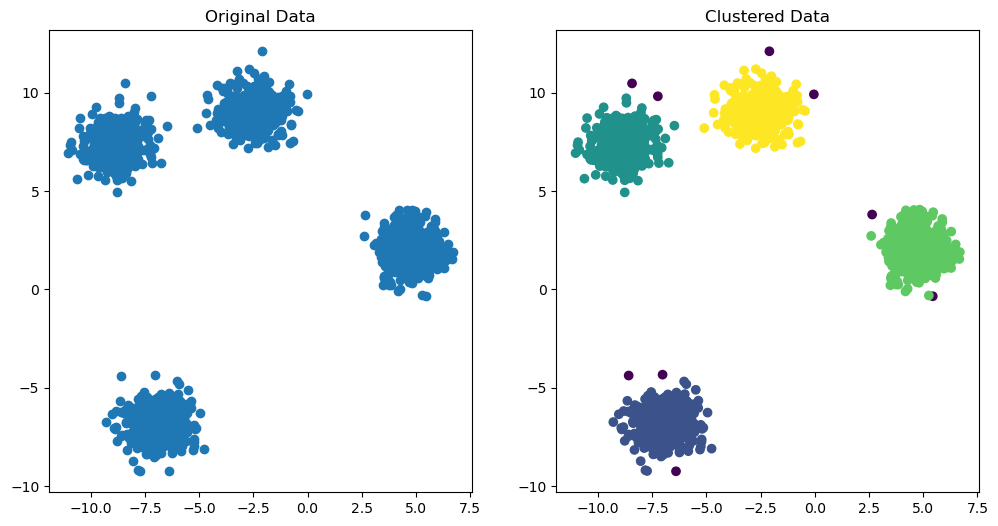

In [156]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# scaling the datasets (Standardization)
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X2_scaled = scaler.fit_transform(X2)
X3_scaled = scaler.fit_transform(X3)

# training DBSCAN model
dbscan = DBSCAN(eps=0.14, min_samples=5)
dbscan.fit(X1_scaled)
labels = dbscan.labels_

# visualizing the clustering
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

ax1.scatter(X1[:, 0], X1[:, 1])
ax1.set_title("Original Data")

ax2.scatter(X1[:, 0], X1[:, 1], c=labels)
ax2.set_title("Clustered Data")

It's obvious that this clustering is not true and needs to be tuned.

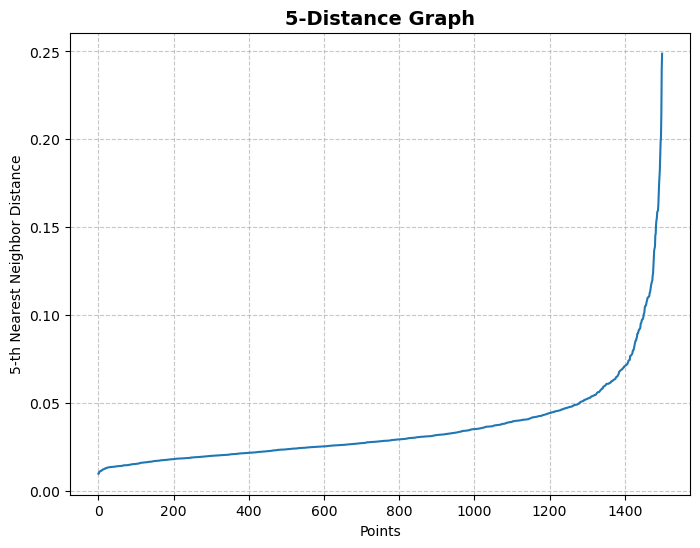

In [133]:
# tuning using elbow method on k-distance graph 
from utils import plot_k_distance_graph

plot_k_distance_graph(X1_scaled, n_neighbors=5)

The best choice for the min_samples and epsilon should choose used grid search.

In [154]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
import numpy as np

eps_range = np.arange(0.05, 0.15, 0.01)
min_samples_range = range(5, 8, 1)

best_score = -1
best_eps = 0
best_min_samples = 0
for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(X1_scaled)
        labels = dbscan.labels_
        score = silhouette_score(X1_scaled, labels)
        
		# prevents one class clustering
        if len(set(labels)) == 1:
            continue
        
        if score > best_score:
            best_score = score
            best_min_samples = min_samples
            best_eps = eps

print(f"Best Score: {best_score}")
print(f"Best eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")

Best Score: 0.8263114494153935
Best eps: 0.14
Best min_samples: 5


This analysis is just a helper to select best params at last you should interpret the results and analyze if they make sense or not. In clustering domain knowledge becomes very important.

Text(0.5, 1.0, 'Clustered Data')

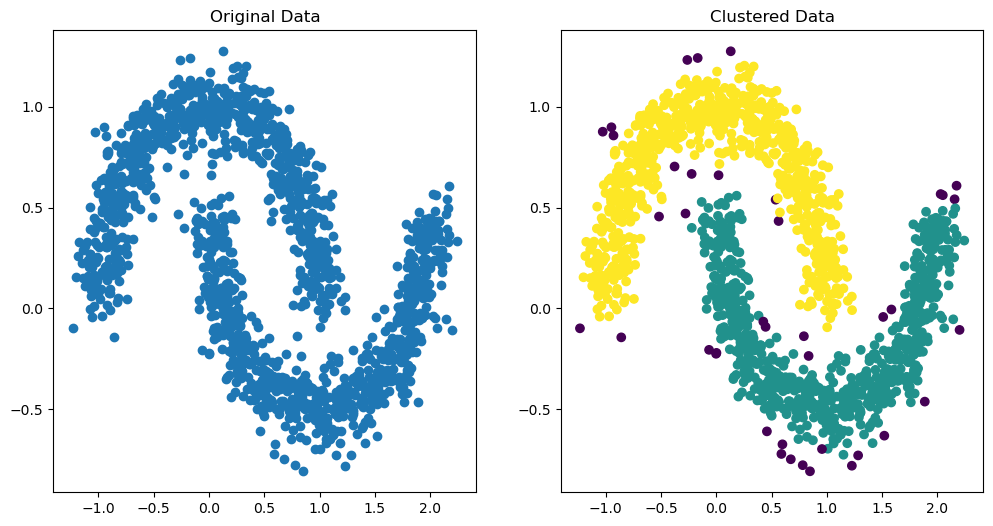

In [175]:
# training DBSCAN model on moons dataset
dbscan = DBSCAN(eps=0.13, min_samples=5) # best params (based-on analysis below)
dbscan.fit(X2_scaled)
labels = dbscan.labels_

# visualizing the clustering
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

ax1.scatter(X2[:, 0], X2[:, 1])
ax1.set_title("Original Data")

ax2.scatter(X2[:, 0], X2[:, 1], c=labels)
ax2.set_title("Clustered Data")

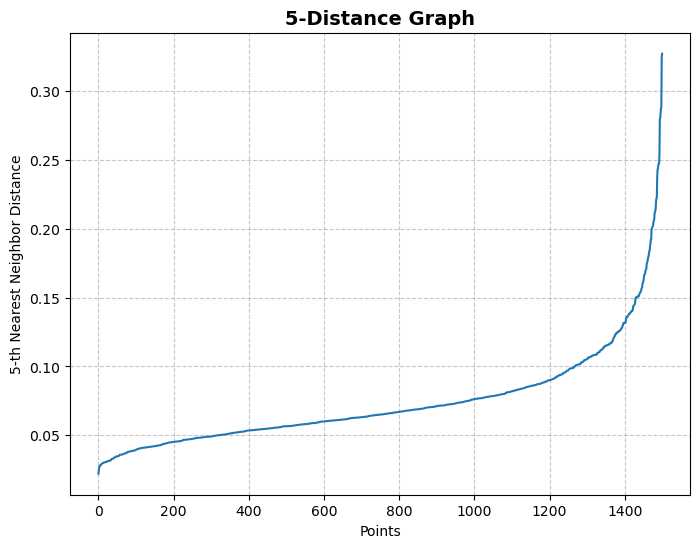

In [177]:
plot_k_distance_graph(X2_scaled, 5)

In [187]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# hyperparameter tuning
param_grid = {
    "eps": np.arange(0.13, 0.2, 0.01),
    "min_samples": range(5, 8)
}

grid = GridSearchCV(
    estimator=DBSCAN(),
    param_grid=param_grid,
    scoring=davies_bouldin_score
)
grid.fit(X2_scaled)

/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 914, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 208, in wrapper
    validate_parameter_constraints(
  File "/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 98, in validate_parameter_constraints
    raise InvalidParameterError(
sklearn.utils._param_validation.InvalidParameterError: The 'X' p

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DBSCAN()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'eps': array([0.13, ..., 0.19, 0.2 ]), 'min_samples': range(5, 8)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function dav...x7436fd5c6520>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [179]:
grid.best_params_

{'eps': np.float64(0.13), 'min_samples': 5}

### **Comparing K-Means and DBSCAN on Moons Dataset:**

Text(0.5, 1.0, 'Clustered Using DBSCAN Algorithm')

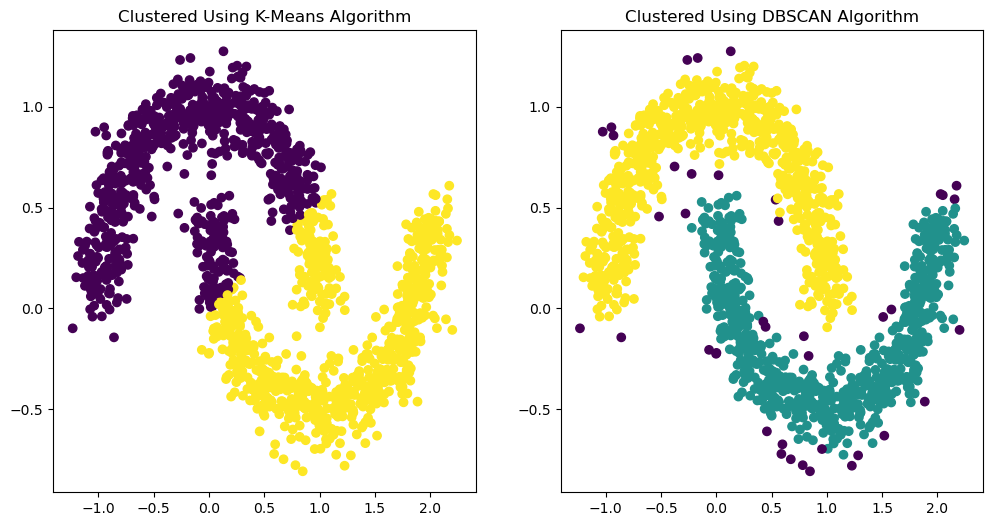

In [186]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X2_scaled)

dbscan = DBSCAN(eps=0.13, min_samples=5) # fine tuned samples
dbscan.fit(X2_scaled)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axs[0].scatter(X2[:, 0], X2[:, 1], c=kmeans.labels_)
axs[0].set_title("Clustered Using K-Means Algorithm")

axs[1].scatter(X2[:, 0], X2[:, 1], c=dbscan.labels_)
axs[1].set_title("Clustered Using DBSCAN Algorithm")

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def plot_k_distance_graph(X, n_neighbors):
	neigh = NearestNeighbors(n_neighbors=n_neighbors)
	neigh.fit(X)
	distances, _ = neigh.kneighbors(X)
	distances = np.sort(distances[:, n_neighbors - 1])

	_, ax = plt.subplots(figsize=(8, 6))

	ax.plot(range(len(distances)), distances)
	ax.set_title(f"{n_neighbors}-Distance Graph", fontsize=14, fontweight="bold")
	ax.set_xlabel("Points")
	ax.set_ylabel(f"{n_neighbors}-th Nearest Neighbor Distance")
	ax.grid(True, linestyle="--", alpha=0.7)